--- Model Trained Successfully! ---
Testing Accuracy Score: 97.40%



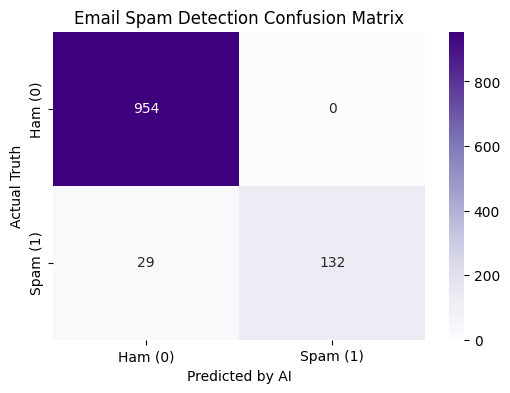

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Use the correct raw data we just verified
df = df_raw.copy()

# 2. Assign the features (X = text sentences) and labels (y = 0 or 1 category)
X = df['sms']
y = df['label']

# 3. Split the data into Training Set (80%) and Testing Set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Turn text words into numbers using TF-IDF Vectorization
# This strips away common words like 'the' or 'is' so the AI focuses on spam keywords
vectorizer = TfidfVectorizer(stop_words='english', lowercase=True)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# 5. Train the Spam Classifier model (Naive Bayes AI)
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# 6. Test the model's predictions on our hidden testing data
y_pred = model.predict(X_test_tfidf)

# 7. Print out the final testing accuracy score
accuracy = accuracy_score(y_test, y_pred)
print("--- Model Trained Successfully! ---")
print(f"Testing Accuracy Score: {accuracy * 100:.2f}%\n")

# 8. Draw a beautiful Confusion Matrix heat-grid chart
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Ham (0)', 'Spam (1)'], yticklabels=['Ham (0)', 'Spam (1)'])
plt.title('Email Spam Detection Confusion Matrix')
plt.xlabel('Predicted by AI')
plt.ylabel('Actual Truth')
plt.show()